# Week 4 Task: Ensemble Methods (Random Forest, XGBoost) vs Baseline Regression

## Objective
Train two ensemble regression models:
- Random Forest Regressor
- XGBoost Regressor

Then compare them against a baseline regression model:
- Linear Regression

## Dataset (Kaggle)
We use the Kaggle dataset: **Red Wine Quality**  
Target column: **quality** (regression)

In [23]:
# =========================================
# PHASE 1A: PROJECT SETUP & DATA (KAGGLE)
# =========================================

!pip -q install kaggle

from google.colab import files
files.upload()  # upload kaggle.json

!mkdir -p /root/.kaggle
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

DATASET_SLUG = "uciml/red-wine-quality-cortez-et-al-2009"
!kaggle datasets download -d {DATASET_SLUG} -p /content --force

import zipfile, os, glob
extract_dir = "/content/kaggle_data"
os.makedirs(extract_dir, exist_ok=True)

zip_path = sorted(glob.glob("/content/*.zip"), key=os.path.getmtime, reverse=True)[0]
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_dir)

import pandas as pd
csv_path = glob.glob(extract_dir + "/**/*.csv", recursive=True)[0]
df = pd.read_csv(csv_path)

print("Loaded:", csv_path)
print("Shape:", df.shape)
df.head()

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009
License(s): DbCL-1.0
  0% 0.00/25.6k [00:00<?, ?B/s]
100% 25.6k/25.6k [00:00<00:00, 65.2MB/s]
Loaded: /content/kaggle_data/winequality-red.csv
Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


# Phase 2 — Exploratory Data Analysis

Before training machine learning models, we analyze the dataset to understand:

- data types
- missing values
- statistical properties
- relationships between variables

The target variable we want to predict is **wine quality**.

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None

Statistical Summary
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.00

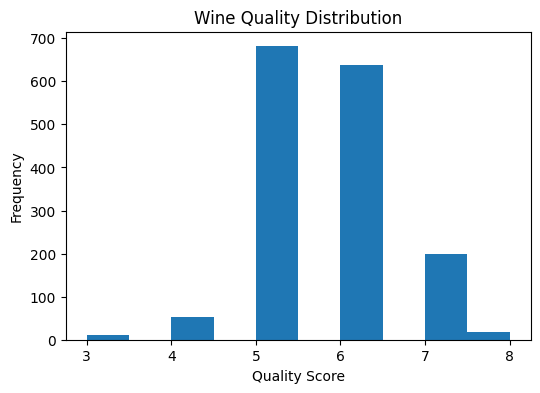

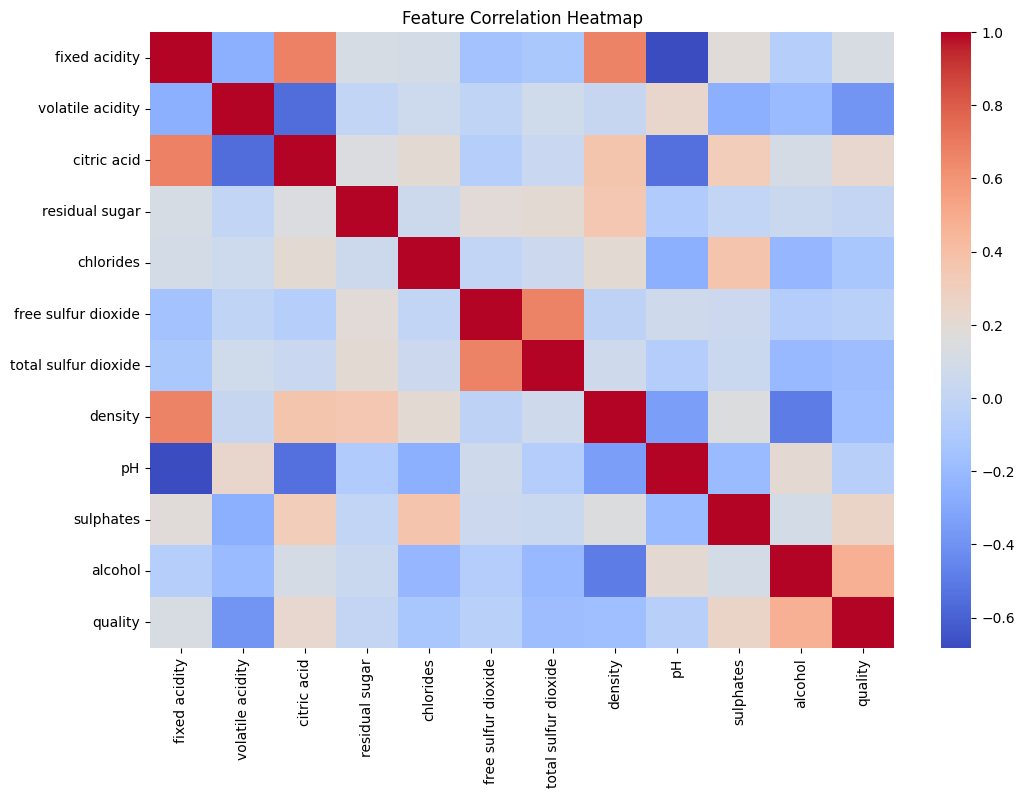

In [26]:
# =========================================
# PHASE 2: DATA EXPLORATION
# =========================================

import matplotlib.pyplot as plt
import seaborn as sns

print("Dataset Info")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

# Target Distribution
plt.figure(figsize=(6,4))
plt.hist(df["quality"], bins=10)
plt.title("Wine Quality Distribution")
plt.xlabel("Quality Score")
plt.ylabel("Frequency")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# Phase 3 — Feature Preparation

We now prepare the dataset for machine learning.

By:
1. Separate features and target
2. Split the dataset into training and testing sets
3. Prepare evaluation metrics

In [27]:
# =========================================
# PHASE 3: FEATURE PREPARATION
# =========================================

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Features and Target
X = df.drop("quality", axis=1)
y = df["quality"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

# Evaluation Function
def evaluate_model(name, y_true, preds):

    rmse = np.sqrt(mean_squared_error(y_true, preds))
    mae = mean_absolute_error(y_true, preds)
    r2 = r2_score(y_true, preds)

    print(f"\n{name} Results")
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)

    return rmse, mae, r2

Training size: (1279, 11)
Testing size: (320, 11)


# Phase 4 — Baseline Regression Model

We begin with a simple regression model:

**Linear Regression**

This model serves as a baseline to evaluate whether ensemble methods provide improved performance.


Linear Regression Results
RMSE: 0.6245199307980125
MAE : 0.5035304415524375
R2  : 0.403180341279623


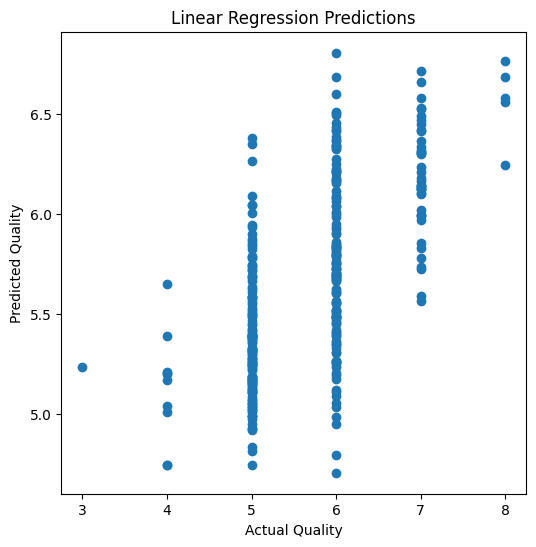

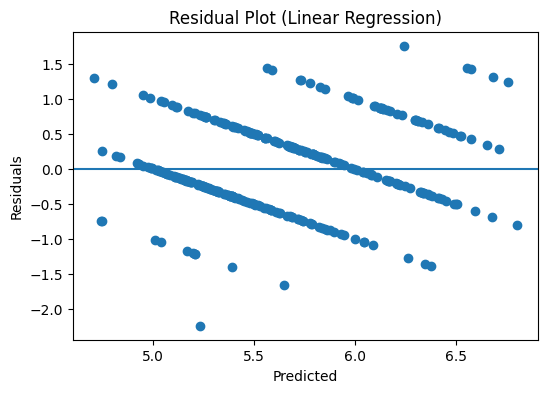

In [28]:
# =========================================
# PHASE 4: BASELINE MODEL
# =========================================

from sklearn.linear_model import LinearRegression

baseline_model = LinearRegression()

baseline_model.fit(X_train, y_train)

baseline_preds = baseline_model.predict(X_test)

rmse_lr, mae_lr, r2_lr = evaluate_model(
    "Linear Regression", y_test, baseline_preds
)

# Prediction Plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, baseline_preds)
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Linear Regression Predictions")
plt.show()

# Residual Plot
residuals = y_test - baseline_preds

plt.figure(figsize=(6,4))
plt.scatter(baseline_preds, residuals)
plt.axhline(0)
plt.title("Residual Plot (Linear Regression)")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

# Phase 5 — Ensemble Model: Random Forest
Random Forest is an ensemble method that builds many decision trees and averages their predictions.


Random Forest Results
RMSE: 0.5535718612389502
MAE : 0.42375000000000007
R2  : 0.5310802479282583


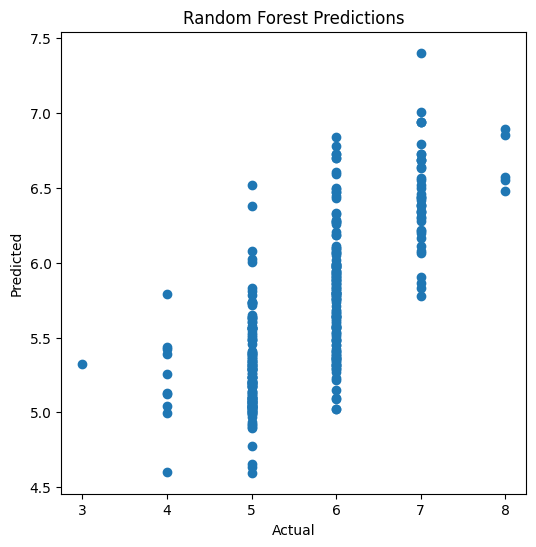

In [29]:
# =========================================
# PHASE 5: RANDOM FOREST MODEL
# =========================================

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

rmse_rf, mae_rf, r2_rf = evaluate_model(
    "Random Forest", y_test, rf_preds
)

# Prediction Plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_preds)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest Predictions")
plt.show()

# Phase 6 — Ensemble Model: XGBoost
XGBoost is a gradient boosting algorithm that often achieves strong performance on structured datasets.


XGBoost Results
RMSE: 0.6007539591648862
MAE : 0.46709388494491577
R2  : 0.44773972034454346


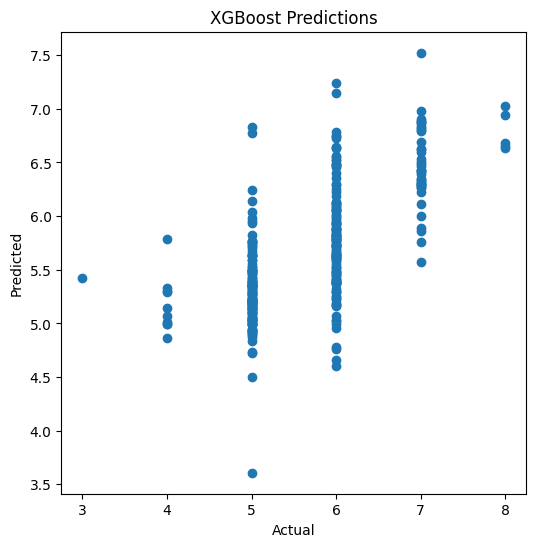

In [30]:
# =========================================
# PHASE 6: XGBOOST MODEL
# =========================================

!pip -q install xgboost

from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)

rmse_xgb, mae_xgb, r2_xgb = evaluate_model(
    "XGBoost", y_test, xgb_preds
)

# Prediction Plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, xgb_preds)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("XGBoost Predictions")
plt.show()

# Phase 7 — Model Comparison

               Model      RMSE       MAE       R2
0  Linear Regression  0.624520  0.503530  0.40318
1      Random Forest  0.553572  0.423750  0.53108
2            XGBoost  0.600754  0.467094  0.44774


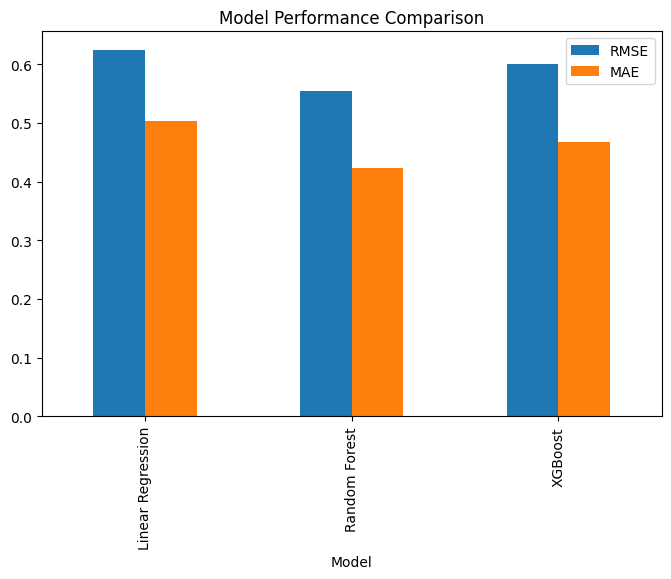

In [31]:
# =========================================
# PHASE 7: MODEL COMPARISON
# =========================================

import pandas as pd

results = pd.DataFrame({
    "Model":["Linear Regression","Random Forest","XGBoost"],
    "RMSE":[rmse_lr, rmse_rf, rmse_xgb],
    "MAE":[mae_lr, mae_rf, mae_xgb],
    "R2":[r2_lr, r2_rf, r2_xgb]
})

print(results)

# Visualization
results.set_index("Model")[["RMSE","MAE"]].plot(
    kind="bar",
    figsize=(8,5),
    title="Model Performance Comparison"
)

plt.show()

# Phase 8 — Feature Importance

Ensemble tree models can estimate **feature importance**, showing which input variables contribute most to predictions.

We will extract and visualize feature importances from:
- Random Forest Regressor
- XGBoost Regressor

This does **not** prove causation, but it helps interpret how models are using the input features.

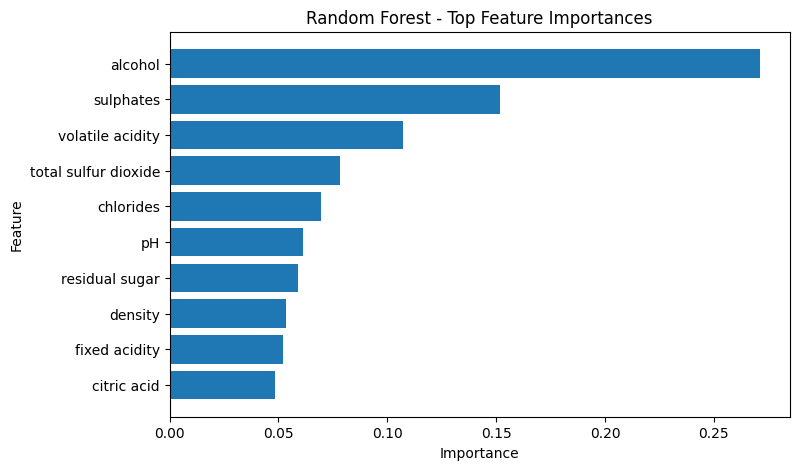

Top Random Forest Features:


,feature,importance
10,alcohol,0.271277
9,sulphates,0.151592
1,volatile acidity,0.107264
6,total sulfur dioxide,0.078176
4,chlorides,0.069370
8,pH,0.061289
3,residual sugar,0.058843
7,density,0.053556
0,fixed acidity,0.052189
2,citric acid,0.048250


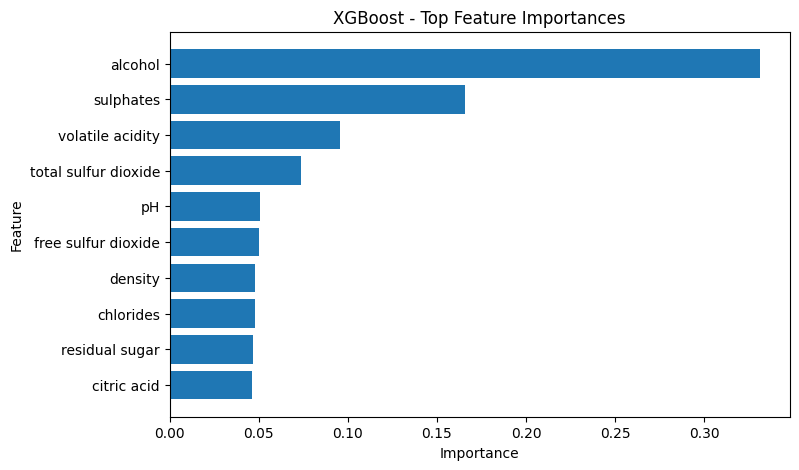

Top XGBoost Features:


,feature,importance
10,alcohol,0.331328
9,sulphates,0.165771
1,volatile acidity,0.095686
6,total sulfur dioxide,0.073819
8,pH,0.050775
5,free sulfur dioxide,0.049967
7,density,0.047824
4,chlorides,0.047796
3,residual sugar,0.046782
2,citric acid,0.046172


In [32]:
# =========================================
# PHASE 8: FEATURE IMPORTANCE (RF + XGB)
# =========================================

import pandas as pd
import matplotlib.pyplot as plt

feature_names = X.columns.tolist()

# ---- Random Forest Feature Importance ----
rf_importances = rf.feature_importances_
rf_imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_importances
}).sort_values("importance", ascending=False)

top_n = 10

plt.figure(figsize=(8,5))
plt.barh(rf_imp_df["feature"].head(top_n)[::-1], rf_imp_df["importance"].head(top_n)[::-1])
plt.title("Random Forest - Top Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

print("Top Random Forest Features:")
display(rf_imp_df.head(top_n))


# ---- XGBoost Feature Importance ----
# Note: XGBoost also provides feature importances
xgb_importances = xgb.feature_importances_
xgb_imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,5))
plt.barh(xgb_imp_df["feature"].head(top_n)[::-1], xgb_imp_df["importance"].head(top_n)[::-1])
plt.title("XGBoost - Top Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

print("Top XGBoost Features:")
display(xgb_imp_df.head(top_n))

# Graphs

1. **Predicted vs Actual plot**
   - If points cluster close to a diagonal line, the model predicts well.
   - If points are scattered, the model struggles to generalize.

2. **Residual plot**
   - Ideal residuals are centered around 0 with no clear pattern.
   - Patterns suggest bias (missing relationships) or heteroscedasticity.

3. **Feature importance**
   - Shows which chemical properties the models consider most influential for predicting wine quality.
   - Different models may rank features differently.

# Phase 9 — Residual Diagnostics (Histogram + Residuals vs Predicted)

Residual analysis helps validate model behavior.

We will generate, for each model (Linear Regression, Random Forest, XGBoost):
1. **Residual Histogram** — checks if errors are centered around 0 and how spread they are.
2. **Residuals vs Predicted Plot** — checks if errors show patterns (bias / non-constant variance).

Good sign:
- residuals roughly centered around 0
- no clear curve/pattern in residuals vs predicted

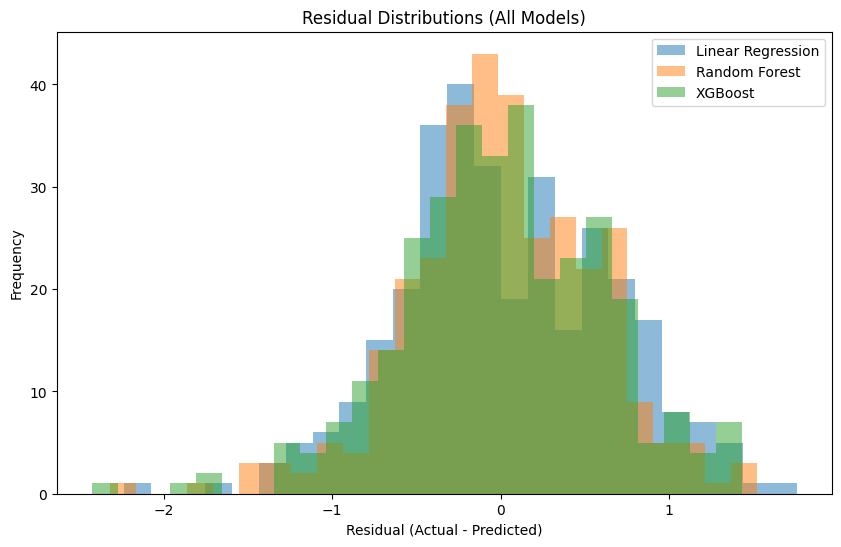

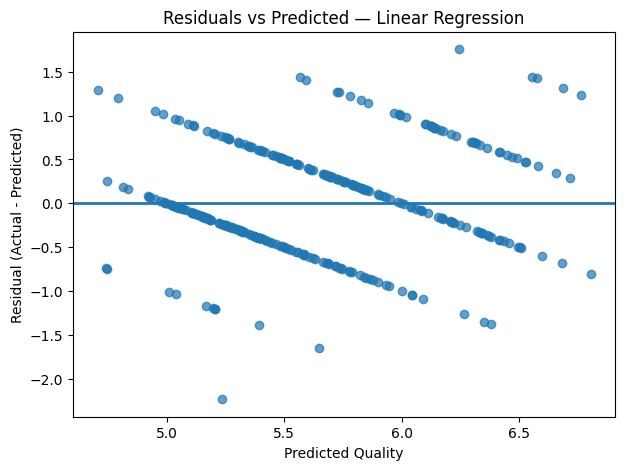

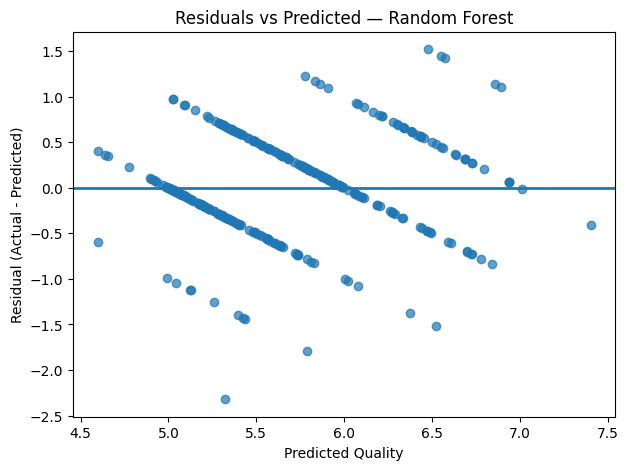

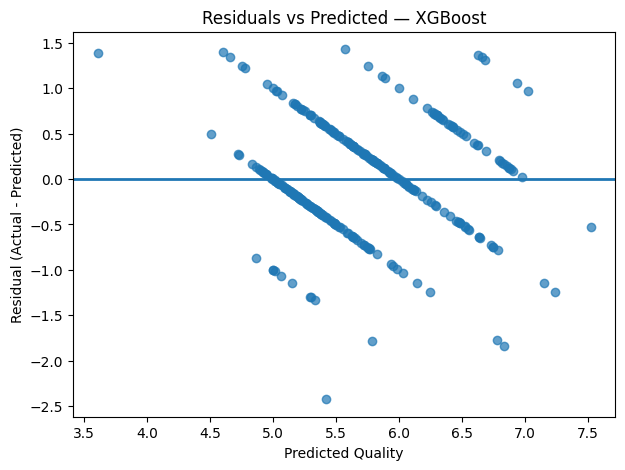

,Model,Residual Mean,Residual Std,Residual Min,Residual Max
0,Linear Regression,0.032969,0.623649,-2.233869,1.756051
1,Random Forest,0.011750,0.553447,-2.320000,1.520000
2,XGBoost,0.006816,0.600715,-2.424944,1.430699


In [33]:
# =========================================
# PHASE 9: RESIDUAL DIAGNOSTICS (ALL MODELS)
# =========================================

import matplotlib.pyplot as plt
import numpy as np

# Ensure we have predictions (from earlier phases)
# baseline_preds, rf_preds, xgb_preds already computed

models_preds = {
    "Linear Regression": baseline_preds,
    "Random Forest": rf_preds,
    "XGBoost": xgb_preds
}

# Create residuals
residuals_dict = {name: (y_test - preds) for name, preds in models_preds.items()}

# 1) Residual Histograms
plt.figure(figsize=(10,6))
for name, res in residuals_dict.items():
    plt.hist(res, bins=25, alpha=0.5, label=name)
plt.title("Residual Distributions (All Models)")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# 2) Residuals vs Predicted (one plot per model for clarity)
for name, preds in models_preds.items():
    res = residuals_dict[name]
    plt.figure(figsize=(7,5))
    plt.scatter(preds, res, alpha=0.7)
    plt.axhline(0, linewidth=2)
    plt.title(f"Residuals vs Predicted — {name}")
    plt.xlabel("Predicted Quality")
    plt.ylabel("Residual (Actual - Predicted)")
    plt.show()

# Quick numeric summary
summary_rows = []
for name, res in residuals_dict.items():
    summary_rows.append({
        "Model": name,
        "Residual Mean": float(np.mean(res)),
        "Residual Std": float(np.std(res)),
        "Residual Min": float(np.min(res)),
        "Residual Max": float(np.max(res))
    })

import pandas as pd
pd.DataFrame(summary_rows)